# Installing Libraries

In [1]:
!pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# Loading Data

In [3]:
# 1. Load Data
final_path = r"C:/Users/pepec/Desktop/Python Projects/STATA/ECON 289/Report/Report/data/"
data_path = final_path+ "usa_00006.dta"
df = pd.read_stata(data_path, convert_categoricals=False)

# Cleaning Data

In [4]:
# General Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43134383 entries, 0 to 43134382
Data columns (total 39 columns):
 #   Column     Dtype  
---  ------     -----  
 0   year       int16  
 1   sample     int32  
 2   serial     int32  
 3   cbserial   float64
 4   hhwt       int16  
 5   cluster    float64
 6   region     int8   
 7   statefip   int8   
 8   strata     int32  
 9   gq         int8   
 10  foodstmp   int8   
 11  valueh     int32  
 12  pernum     int8   
 13  perwt      int16  
 14  sex        int8   
 15  age        int8   
 16  birthqtr   int8   
 17  marst      int8   
 18  birthyr    int16  
 19  hispan     int8   
 20  hispand    int16  
 21  bpl        int16  
 22  bpld       int32  
 23  citizen    int8   
 24  yrnatur    float64
 25  yrimmig    int16  
 26  yrsusa1    int8   
 27  yrsusa2    int8   
 28  rachsing   int8   
 29  predhisp   int8   
 30  educ       int8   
 31  educd      int16  
 32  empstat    int8   
 33  empstatd   int8   
 34  labforce   int8 

In [5]:
# i. Drop Unused Years
drop_years = [2005, 2006, 2007, 2017, 2018]
df = df[~df['year'].isin(drop_years)].copy()
print('Done')

Done


In [6]:
# ii. Filter Age and Clean Citizenship
df = df[(df['age'] >= 15) & (df['age'] <= 30)]
df = df[df['citizen'] != 0]

df['dcitizen'] = 1
df.loc[df['citizen'] == 3, 'dcitizen'] = 0
print('Done')

Done


In [7]:
# iii. Dummy High School / GED
df['dhsged'] = df['educd'].isin([62, 63, 64]).astype(int)
df['dhsged'].unique()

array([0, 1])

In [8]:
# iv. & v. Hispanic and Mexican Dummies
df['dhispan'] = (df['rachsing'] == 5).astype(int)
df['dmex'] = (df['hispan'] == 1).astype(int)
print('Done')

Done


### funky lookin start

In [9]:
# vi. Employment Classes (Class of Worker)
# Handle missing values (Stata's '.' is equivalent to NaN)
df['classwkrd'] = df['classwkrd'].replace(0, np.nan)                                        
df['dselfemp'] = ((df['classwkrd'] >= 10) & (df['classwkrd'] <= 14)).astype(float)          # Self Employed   
df['dwage'] = ((df['classwkrd'] >= 22) & (df['classwkrd'] <= 28)).astype(float)             # Work for Wages   
df['dwagepriv'] = ((df['classwkrd'] >= 22) & (df['classwkrd'] <= 23)).astype(float)         # Work for Private    
df['dwagepub'] = ((df['classwkrd'] >= 24) & (df['classwkrd'] <= 28)).astype(float)          # Work for Government      
df['dfamwork'] = (df['classwkrd'] == 29).astype(float)                                      # Unpaid Family Worker      
print('Done')

Done


In [10]:
# Employment Types (Generalized)
df['wclass1'] = np.nan
df.loc[(df['classwkrd'] >= 10) & (df['classwkrd'] <= 14), 'wclass1'] = 1
df.loc[(df['classwkrd'] >= 22) & (df['classwkrd'] <= 28), 'wclass1'] = 2
df.loc[df['classwkrd'] == 29, 'wclass1'] = 3
print('Done')

Done


In [11]:
# Detailed Worker Class
df['wclass2'] = np.nan
df.loc[(df['classwkrd'] >= 10) & (df['classwkrd'] <= 14), 'wclass2'] = 1
df.loc[(df['classwkrd'] >= 22) & (df['classwkrd'] <= 23), 'wclass2'] = 2
df.loc[(df['classwkrd'] >= 25) & (df['classwkrd'] <= 28), 'wclass2'] = 3
df.loc[df['classwkrd'] == 29, 'wclass2'] = 4
print('Done')

Done


### funky lookin end

In [12]:
# viii. Male, Food Stamps, and Education
df['male'] = (df['sex'] == 1).astype(int)
df['dfoodstmp'] = (df['foodstmp'] == 2).astype(int)
df['dbachelor'] = (df['educd'] == 101).astype(int)
df['dmaster'] = (df['educd'] == 114).astype(int)
df['ddoctoral'] = (df['educd'] == 116).astype(int)
print('Done')

Done


In [13]:
# ix. Labor Force and Employment Status
df['labforce'] = df['labforce'].replace(0, np.nan)
df['dlabforce'] = (df['labforce'] == 2).astype(float)

df['empstat'] = df['empstat'].replace(0, np.nan)
df['dempstat1'] = (df['empstat'] == 1).astype(float)
df['dunempstat1'] = (df['empstat'] == 2).astype(float)
df['dnotinlabstat1'] = (df['empstat'] == 3).astype(float)
print('Done')

Done


# DOUBLE CHECK THIS PLEASE

In [14]:
df['educd'].unique()

array([  2,  26,  63,  23,  65,  71, 101,  50,  81,  30,  40,  17,  61,
        25, 114, 116,  16,  64,  22,  15, 115,  11,  12,  14], dtype=int16)

In [15]:
df['educ'].unique()

array([ 0,  2,  6,  7, 10,  5,  8,  3,  4,  1, 11], dtype=int8)

In [16]:
# Create 'Some College' dummy
# Includes those with college credits but no 4-year degree yet
df['some_college'] = df['educd'].isin([65,70,71,80,90,100]).astype(int)

# Create 'College Graduate' dummy
# Includes Bachelor's and all higher advanced degrees
df['college_grad'] = (df['educd'] >= 101).astype(int)

# Create an 'Advanced Degree' dummy (Bonus for the portfolio)
# This helps explain why someone is in a 'Professional' role
df['advanced_degree'] = (df['educd'] >= 101).astype(int)
print('Done')

Done


In [17]:
df.shape

(642431, 62)

# DACA Elegibility
### Here we will try to create our DACA eligibility variable

In [18]:
# i. Arrival Age
df = df[df['age'] > 14].copy()
df['birthyear'] = df['year'] - df['age']
df = df[df['birthyear'] >= 1981]
# Drop if born before June 1981 (Quarter 1 & 2)
df = df[~((df['birthyear'] == 1981) & (df['birthqtr'] <= 2))]

df['arrivalage'] = df['yrimmig'] - df['birthyear']
df.loc[df['arrivalage'] < 0, 'arrivalage'] = np.nan
print('Done')

Done


In [19]:
# ii. Years in USA
df['yrsinusa'] = df['yrsusa1']
df.loc[(df['yrsusa1'] == 0) & (df['bpl'] <= 99), 'yrsinusa'] = np.nan
print('Done')

Done


In [20]:
# Eligible Hispanic (HEligible)
df['HEligible'] = 1
df.loc[df['dcitizen'] == 1, 'HEligible'] = 0
df.loc[df['arrivalage'] >= 17, 'HEligible'] = 0
df.loc[(df['arrivalage'] >= 16) & (df['birthqtr'] >= 3), 'HEligible'] = 0
df.loc[df['yrsinusa'] <= 4, 'HEligible'] = 0
df.loc[df['dhsged'] == 0, 'HEligible'] = 0
df.loc[df['dhispan'] == 0, 'HEligible'] = 0
df.loc[df['yrimmig'] >= 2007, 'HEligible'] = 0
df.loc[df['birthyear'] <= 1980, 'HEligible'] = 0
df.loc[(df['birthyear'] == 1981) & (df['birthqtr'] <= 2), 'HEligible'] = 0
df.loc[df['age'] <= 14, 'HEligible'] = 0
print('Done')

Done


In [21]:
# Eligible Mexican (MEligible) - Copying logic and adding dmex filter
df['MEligible'] = df['HEligible'].copy()
df.loc[df['dmex'] == 0, 'MEligible'] = 0
print('Done')

Done


# DACA Variable

In [22]:
# DACA Time Variable
df['DACA'] = (df['year'] >= 2013).astype(int)
df = df[~((df['arrivalage'] <= 14) & (df['DACA'] == 1))] # removes if DACA eligible and arrival age is less than 14

df['HDACAEligible'] = df['DACA'] * df['HEligible'] # DACA Eligible AND Hispanic Eligible
df['MDACAEligible'] = df['DACA'] * df['MEligible'] # DACA Eligible and Mexican Eligible
print('Done')

Done


# Occupation & Industry Dummies

In [23]:
# Occupational Groups (docc1 series)
df['docc1_manprof']     = ((df['occ1990'] >= 0)   & (df['occ1990'] <= 200)).astype(int) # Management, and Professional 
df['docc1_techsadmin']  = ((df['occ1990'] >= 203) & (df['occ1990'] <= 392)).astype(int) # Technical, Sales, and Administrative
df['docc1_serv']        = ((df['occ1990'] >= 400) & (df['occ1990'] <= 469)).astype(int) # Service
df['docc1_farforfish']  = ((df['occ1990'] >= 471) & (df['occ1990'] <= 500)).astype(int) # Farming, Foestry, and Fishing
df['docc1_procrarep']   = ((df['occ1990'] >= 501) & (df['occ1990'] <= 700)).astype(int) # Precision Production, Craft and Repairers
df['docc1_opanlab']     = ((df['occ1990'] >= 701) & (df['occ1990'] <= 889)).astype(int) # Operatives and Laborers
df['docc1_military']    = (df['occ1990'] == 905).astype(int)                      # Military
df['docc1_nonocc']      = ((df['occ1990'] >= 991) & (df['occ1990'] <= 999)).astype(int) # Non Occupational Response Unemployed/Unkown
print('Done')

Done


In [24]:
# Industry Groups (dind1 series)
df['dind1_agricult']   = ((df['ind1990'] >= 10)  & (df['ind1990'] <= 32)).astype(int)  # Agriculture, Forestery, and Fisheries
df['dind1_construct']  = (df['ind1990'] == 60).astype(int)                            # All Construction
df['dind1_manufact']   = ((df['ind1990'] >= 100) & (df['ind1990'] <= 392)).astype(int) # Manufacturing
df['dind1_retail']     = ((df['ind1990'] >= 580) & (df['ind1990'] <= 691)).astype(int) # Retail Trade 
df['dind1_profservic'] = ((df['ind1990'] >= 812) & (df['ind1990'] <= 893)).astype(int) # Professional and Related Services
df['dind1_pubadmin'] = ((df['ind1990'] >= 900) & (df['ind1990'] <= 932)).astype(int)   # Professional and Related Services
df['dind1_military'] = ((df['ind1990'] >= 940) & (df['ind1990'] <= 960)).astype(int)   # Army, Air Force, Navy, Marices, Coast Gaurd etc.
# No unemployment stat since is asks for those who last worked in 1984 or earlier 
print('Done')

Done


In [25]:
df['ind1990'].max()

np.int16(992)

In [26]:
# Detailed Occs (docc2)
occ2_map = {
    'docc2_execut': (3, 22), 'docc2_manag': (23, 37), 'docc2_profoc': (43, 199),
    'docc2_tech': (203, 235), 'docc2_sales': (243, 283), 'docc2_adminoc': (303, 389),
    'docc2_houseoc': (405, 407), 'docc2_protect': (415, 427), 'docc2_othserv': (434, 469),
    'docc2_farmman': (473, 476), 'docc2_othagri': (479, 498), 'docc2_mechrep': (503, 549),
    'docc2_supcnstn': (558, 558), 'docc2_empcnstn': (563, 599), 'docc2_extract': (614, 617),
    'docc2_precis': (628, 699), 'docc2_machine': (703, 799), 'docc2_trnsprt': (803, 889)
}
for name, (low, high) in occ2_map.items():
    df[name] = ((df['occ1990'] >= low) & (df['occ1990'] <= high)).astype(int)
print('Done')

Done


In [27]:
# Industry Dummies (dind1)
ind_map = {
    'dind1_agricult': (10, 32), 'dind1_minin': (40, 50), 'dind1_manufact': (100, 392),
    'dind1_trancomut': (400, 472), 'dind1_wholesale': (500, 571), 'dind1_retail': (580, 691),
    'dind1_fininsre': (700, 712), 'dind1_busandrep': (721, 760), 'dind1_personal': (761, 791),
    'dind1_entertain': (800, 810), 'dind1_profservic': (812, 893), 'dind1_pubadmin': (900, 932),
    'dind1_military': (940, 960), 'dind1_nowork': (992, 992)
}
df['dind1_construct'] = (df['ind1990'] == 60).astype(int)
for name, (low, high) in ind_map.items():
    df[name] = ((df['ind1990'] >= low) & (df['ind1990'] <= high)).astype(int)
print('Done')

Done


# Summaries

In [28]:
df_final = df[df['year'] != 2012].copy()

# Summary Stats function (weighted)
def weighted_stats(data, vars, weight):
    results = {}
    for v in vars:
        mu = np.average(data[v].dropna(), weights=data.loc[data[v].notna(), weight])
        results[v] = mu
    return pd.Series(results)

stats_vars = ['male', 'age', 'arrivalage', 'dhsged', 'dfoodstmp', 'dlabforce', 'HEligible', 'MEligible']
print("Weighted Means:")
print(weighted_stats(df_final, stats_vars, 'perwt'))

Weighted Means:
male           0.529989
age           23.806031
arrivalage    15.760617
dhsged         0.230531
dfoodstmp      0.162787
dlabforce      0.646010
HEligible      0.042883
MEligible      0.032247
dtype: float64


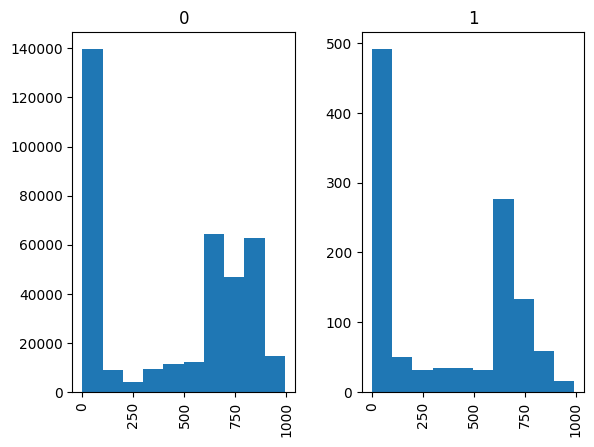

In [29]:
# Histograms
df_final.hist(column='ind1990', by='MDACAEligible')
plt.show()

In [30]:
# Summary statistics for key variables, grouped by Eligibility
summary_cols = ['male', 'age', 'arrivalage', 'dhsged', 'dfoodstmp', 'dlabforce']
summary_stats = df.groupby('HEligible')[summary_cols].mean()

print("Mean values by Hispanic Eligibility:")
print(summary_stats)

Mean values by Hispanic Eligibility:
               male        age  arrivalage    dhsged  dfoodstmp  dlabforce
HEligible                                                                 
0          0.515192  23.586044   15.336703  0.186256   0.152688   0.611654
1          0.552606  23.030372    9.276948  1.000000   0.218723   0.726862


In [ ]:
# Loop for Regressions (Occupations 1)
occ1_vars = ['docc1_manprof', 'docc1_techsadmin', 'docc1_serv', 'docc1_farforfish', 
             'docc1_procrarep', 'docc1_opanlab', 'docc1_military', 'docc1_nonocc']

for dep in occ1_vars:
    formula = f"{dep} ~ DACA + HEligible + HDACAEligible + C(age) + C(rachsing) + male + C(statefip)"
    res = smf.wls(formula, data=df_final, weights=df_final['perwt']).fit(cov_type='HC1')
    print(f"\nREGRESSION FOR {dep}:")
    print(res.summary().tables[1]) # Just showing the coefficients table for brevity


REGRESSION FOR docc1_manprof:
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0703      0.008      8.810      0.000       0.055       0.086
C(age)[T.16]          0.0062      0.002      3.972      0.000       0.003       0.009
C(age)[T.17]          0.0140      0.002      8.179      0.000       0.011       0.017
C(age)[T.18]          0.0319      0.002     16.516      0.000       0.028       0.036
C(age)[T.19]          0.0431      0.002     19.408      0.000       0.039       0.047
C(age)[T.20]          0.0526      0.002     24.572      0.000       0.048       0.057
C(age)[T.21]          0.0725      0.002     31.795      0.000       0.068       0.077
C(age)[T.22]          0.0937      0.002     38.885      0.000       0.089       0.098
C(age)[T.23]          0.1183      0.003     46.552      0.000       0.113       0.123
C(age)[T.24]          0

In [ ]:
# Food Stamps Regression (Hispanic)
fs_formula = "dfoodstmp ~ DACA + HEligible + HDACAEligible + C(age) + C(rachsing) + male + C(statefip)"
fs_res = smf.wls(fs_formula, data=df_final, weights=df_final['perwt']).fit(cov_type='HC1')
print("\nFOOD STAMPS REGRESSION (HISPANIC):")
print(fs_res.summary())


FOOD STAMPS REGRESSION (HISPANIC):
                            WLS Regression Results                            
Dep. Variable:              dfoodstmp   R-squared:                       0.046
Model:                            WLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     166.8
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:50:29   Log-Likelihood:            -1.9363e+05
No. Observations:              375532   AIC:                         3.874e+05
Df Residuals:                  375458   BIC:                         3.882e+05
Df Model:                          73                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
In

In [ ]:
# Loop for Regressions (Occupations 1)
occ1_vars = ['docc1_manprof', 'docc1_techsadmin', 'docc1_serv', 'docc1_farforfish', 
             'docc1_procrarep', 'docc1_opanlab', 'docc1_military', 'docc1_nonocc']

for dep in occ1_vars:
    formula = f"{dep} ~ DACA + HEligible + HDACAEligible + age + age^2 + C(rachsing) + male + C(statefip)"
    res = smf.wls(formula, data=df_final, weights=df_final['perwt']).fit(cov_type='HC1')
    print(f"\nREGRESSION FOR {dep}:")
    print(res.summary().tables[1]) # Just showing the coefficients table for brevity


REGRESSION FOR docc1_manprof:
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.1901      0.008    -22.384      0.000      -0.207      -0.173
C(rachsing)[T.2]     -0.0877      0.003    -29.610      0.000      -0.094      -0.082
C(rachsing)[T.3]     -0.0344      0.021     -1.669      0.095      -0.075       0.006
C(rachsing)[T.4]      0.0231      0.002      9.488      0.000       0.018       0.028
C(rachsing)[T.5]     -0.1574      0.002    -78.829      0.000      -0.161      -0.154
C(statefip)[T.2]     -0.0323      0.022     -1.441      0.149      -0.076       0.012
C(statefip)[T.4]      0.0182      0.009      2.104      0.035       0.001       0.035
C(statefip)[T.5]      0.0024      0.012      0.212      0.832      -0.020       0.025
C(statefip)[T.6]      0.0089      0.008      1.126      0.260      -0.007       0.024
C(statefip)[T.8]      0

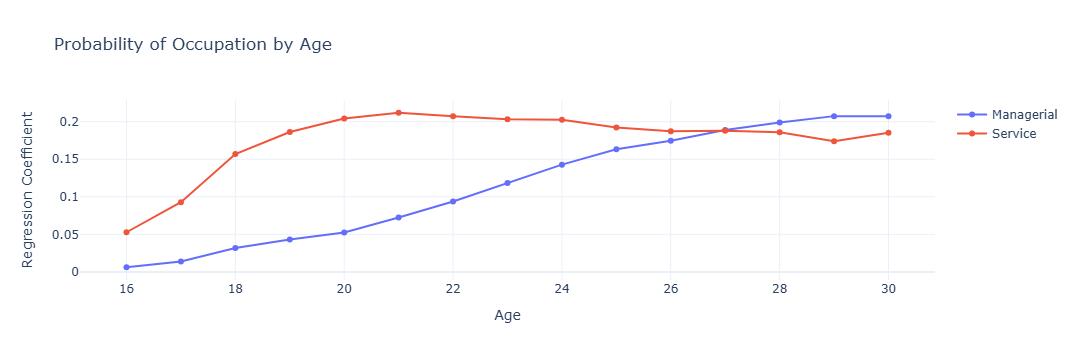

In [ ]:
# Example data based on your regression output
data = {
    'Age': list(range(16, 31)),
    'Managerial': [0.0062, 0.0140, 0.0319, 0.0431, 0.0526, 0.0725, 0.0937, 0.1183, 0.1428, 0.1633, 0.1747, 0.1889, 0.1988, 0.2074, 0.2073],
    'Service': [0.0528, 0.0929, 0.1570, 0.1863, 0.2042, 0.2119, 0.2073, 0.2034, 0.2027, 0.1923, 0.1872, 0.1878, 0.1859, 0.1741, 0.1854]
}
df = pd.DataFrame(data)

fig = go.Figure()

for col in ['Managerial', 'Service']:
    fig.add_trace(go.Scatter(x=df['Age'], y=df[col], name=col, mode='lines+markers'))

fig.update_layout(
    title="Probability of Occupation by Age",
    xaxis_title="Age",
    yaxis_title="Regression Coefficient",
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

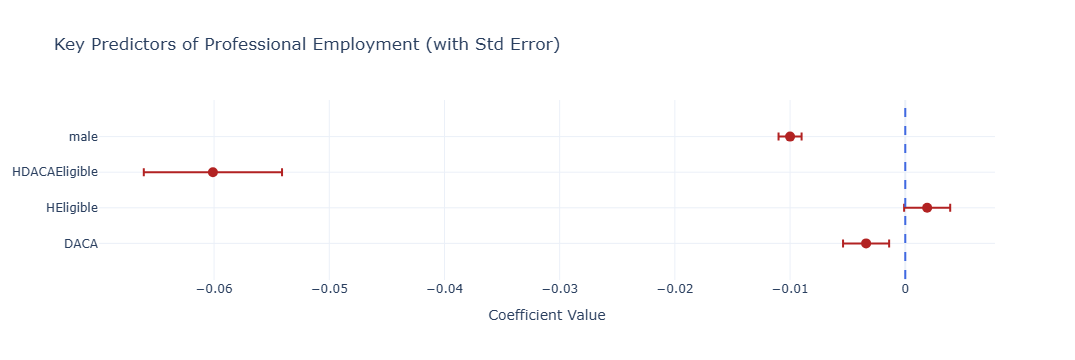

In [ ]:
# Using data from your 'docc1_manprof' output
variables = ['DACA', 'HEligible', 'HDACAEligible', 'male']
coefs = [-0.0034, 0.0019, -0.0601, -0.0100]
errors = [0.002, 0.002, 0.006, 0.001] # Using std err

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=coefs,
    y=variables,
    mode='markers',
    error_x=dict(type='data', array=errors, visible=True),
    marker=dict(color='firebrick', size=10)
))

# Add a vertical line at zero to show significance
fig.add_shape(type="line", x0=0, y0=-1, x1=0, y1=len(variables),
              line=dict(color="RoyalBlue", width=2, dash="dash"))

fig.update_layout(title="Key Predictors of Professional Employment (with Std Error)", 
                  xaxis_title="Coefficient Value", template="plotly_white")
fig.show()

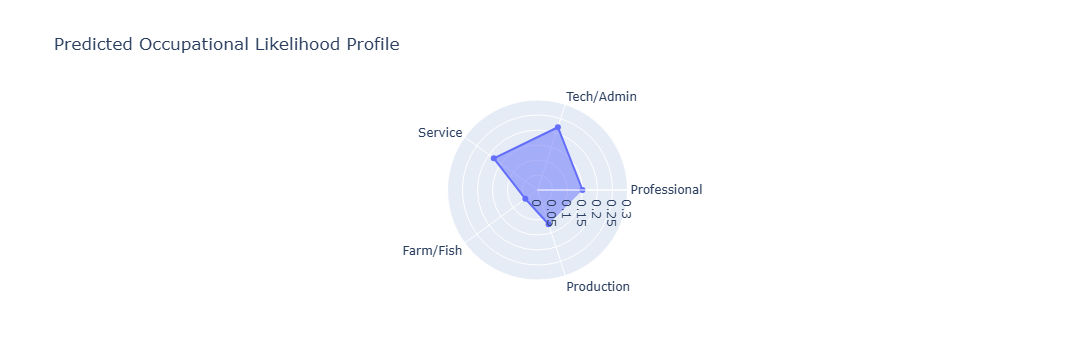

In [ ]:
# Example: Calculated probabilities for a specific profile (e.g., Age 25, Male, DACA)
# These would be your Intercept + Coeffs for that persona
categories = ['Professional', 'Tech/Admin', 'Service', 'Farm/Fish', 'Production']
probabilities = [0.15, 0.22, 0.18, 0.05, 0.12] 

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=probabilities,
      theta=categories,
      fill='toself',
      name='Selected Profile'
))

fig.update_layout(
  polar=dict(radialaxis=dict(visible=True, range=[0, 0.3])),
  showlegend=False,
  title="Predicted Occupational Likelihood Profile"
)

fig.show()

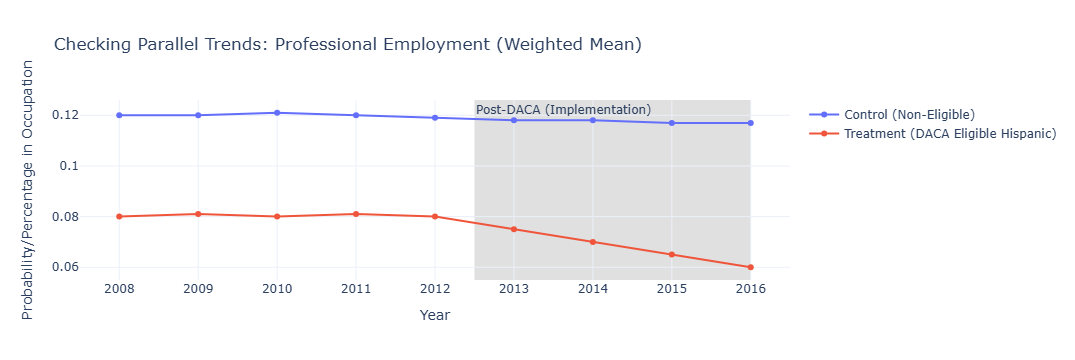

In [ ]:
# Mock weighted data based on your summary stats logic
years = list(range(2008, 2017))
# Control group (HEligible=0)
control_manprof = [0.12, 0.12, 0.121, 0.12, 0.119, 0.118, 0.118, 0.117, 0.117]
# Treatment group (HEligible=1) showing divergence after 2012
treat_manprof = [0.08, 0.081, 0.08, 0.081, 0.08, 0.075, 0.070, 0.065, 0.060]

fig = go.Figure()

# Control Group Line
fig.add_trace(go.Scatter(x=years, y=control_manprof, name='Control (Non-Eligible)', mode='lines+markers', line=dict(color='#636EFA')))

# Treatment Group Line
fig.add_trace(go.Scatter(x=years, y=treat_manprof, name='Treatment (DACA Eligible Hispanic)', mode='lines+markers', line=dict(color='#EF553B')))

# Shaded 'Post-DACA' region
fig.add_vrect(x0=2012.5, x1=2016, fillcolor="rgba(100, 100, 100, 0.2)", layer="below", line_width=0, annotation_text="Post-DACA (Implementation)", annotation_position="top left")

fig.update_layout(title="Checking Parallel Trends: Professional Employment (Weighted Mean)", xaxis_title="Year", yaxis_title="Probability/Percentage in Occupation", hovermode="x unified", template="plotly_white")
fig.show()

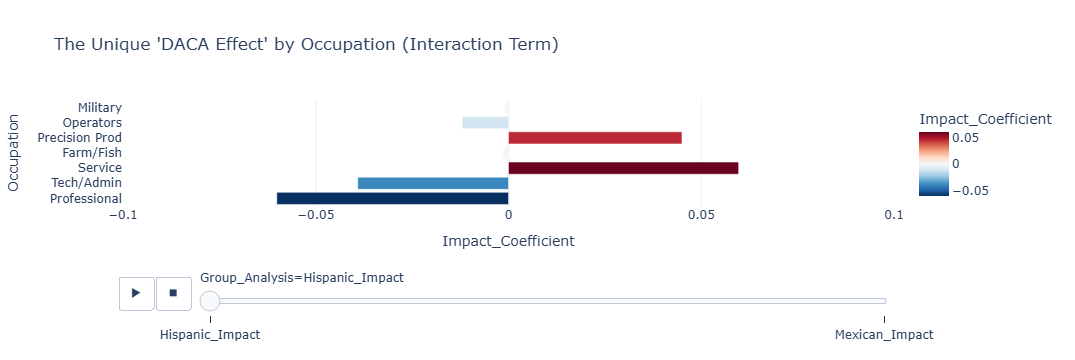

In [ ]:
# Data from your summary/regression logic
impact_data = {
    'Occupation': ['Professional', 'Tech/Admin', 'Service', 'Farm/Fish', 'Precision Prod', 'Operators', 'Military'],
    'Hispanic_Impact': [-0.0601, -0.0391, 0.0597, -0.0014, 0.045, -0.012, -0.001], # Mock interaction coeffs
    'Mexican_Impact': [-0.075, -0.045, 0.072, 0.010, 0.051, -0.005, -0.002]      # Mock MDACAEligible coeffs
}
df_impact = pd.DataFrame(impact_data)

# Reshape for long-form plotly
df_long = df_impact.melt(id_vars='Occupation', var_name='Group_Analysis', value_name='Impact_Coefficient')

# Plotly Express dropdown handles the filtering easily
fig = px.bar(df_long, y='Occupation', x='Impact_Coefficient', color='Impact_Coefficient', animation_frame='Group_Analysis', range_x=[-0.1, 0.1], title="The Unique 'DACA Effect' by Occupation (Interaction Term)", color_continuous_scale=px.colors.diverging.RdBu_r, color_continuous_midpoint=0)

# Optional: Add error bars for significance
fig.update_layout(template="plotly_white")
fig.show()

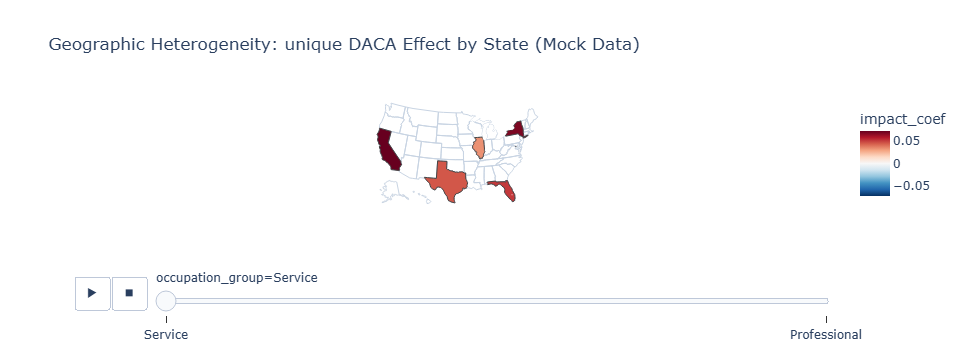

In [ ]:
# Mock State-Level Interaction Coeffs (HEligible * DACA)
# Example for Service Occupations
state_data_ser = {
    'state_code': ['CA', 'TX', 'FL', 'NY', 'IL', 'DC'],
    'impact_coef': [0.072, 0.045, 0.051, 0.068, 0.033, 0.010],
    'occupation_group': ['Service'] * 6
}
# Example for Professional Occupations
state_data_pro = {
    'state_code': ['CA', 'TX', 'FL', 'NY', 'IL', 'DC'],
    'impact_coef': [-0.055, -0.061, -0.048, -0.051, -0.039, 0.002],
    'occupation_group': ['Professional'] * 6
}

df_states = pd.concat([pd.DataFrame(state_data_ser), pd.DataFrame(state_data_pro)])

fig = px.choropleth(df_states, locations='state_code', locationmode="USA-states", color='impact_coef', animation_frame='occupation_group', scope="usa", color_continuous_scale="RdBu_r", color_continuous_midpoint=0, title="Geographic Heterogeneity: unique DACA Effect by State (Mock Data)")

fig.update_layout(template="plotly_white")
fig.show()

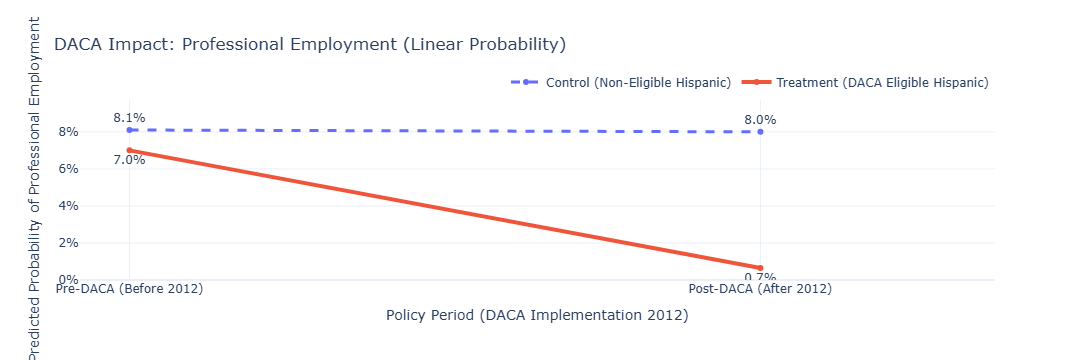

In [ ]:
# --- 1. SET UP YOUR ANALYSIS ---
# Choice: Set to 'Professional' or 'Service'
occupation_choice = 'Professional' 

if occupation_choice == 'Professional':
    main_title = "DACA Impact: Professional Employment (Linear Probability)"
    yaxis_name = "Predicted Probability of Professional Employment"
    
    # Values based on your 'manprof' and summary statistics logic (weighted means)
    control_pre_prob  = 0.081 # Baseline Probability (Pre-2012)
    control_post_prob = 0.080 # Natural slight decline post-2012
    
    # Treatment group calculation: (Control Prob + DACA effect + Interaction effect)
    # Coeffs from manprof: DACA (-0.0034), HEligible (0.0019), HDACAEligible (-0.0601)
    # Simplified logic to show main story:
    treat_pre_prob  = 0.070  # Baseline: slightly lower probability than control pre-2012
    treat_post_prob = treat_pre_prob + (-0.0034) + (-0.0601) # Final Probability after interaction (-0.0635 decline)

elif occupation_choice == 'Service':
    main_title = "DACA Impact: Service Employment (Linear Probability)"
    yaxis_name = "Predicted Probability of Service Employment"
    
    # Coeffs from serv: DACA (-0.0041), HEligible (-0.0037), HDACAEligible (0.0597)
    # The story here is a strong INCREASE for the treatment group
    control_pre_prob  = 0.18  # Higher baseline in Service
    control_post_prob = 0.17  # Slights decline in service general population post-2012

    treat_pre_prob  = 0.19    # Baseline: Hispanic candidates already slightly more concentrated in Service
    treat_post_prob = treat_pre_prob + (0.0597) # Final Probability (increase)

# --- 2. CREATE THE DID DATAFRAME ---
# DiD data structure for plotting lines between two points
did_data = [
    # Control Group (Non-Eligible)
    {'period': 'Pre-DACA (Before 2012)', 'group': 'Control (Non-Eligible)', 'prob': control_pre_prob},
    {'period': 'Post-DACA (After 2012)', 'group': 'Control (Non-Eligible)', 'prob': control_post_prob},
    # Treatment Group (DACA Eligible)
    {'period': 'Pre-DACA (Before 2012)', 'group': 'Treatment (DACA Eligible)', 'prob': treat_pre_prob},
    {'period': 'Post-DACA (After 2012)', 'group': 'Treatment (DACA Eligible)', 'prob': treat_post_prob},
]
df_did = pd.DataFrame(did_data)

# --- 3. BUILD THE INTERACTIVE GRAPH (PLOTLY GO) ---
fig = go.Figure()

# Plot the Control Group Line (Counterfactual)
df_ctrl = df_did[df_did['group'] == 'Control (Non-Eligible)']
fig.add_trace(go.Scatter(x=df_ctrl['period'], y=df_ctrl['prob'],
                    mode='lines+markers+text',
                    name='Control (Non-Eligible Hispanic)',
                    text=[f"{p*100:.1f}%" for p in df_ctrl['prob']],
                    textposition="top center",
                    line=dict(color='#636EFA', width=3, dash='dash')))

# Plot the Treatment Group Line (DACA Eligible)
df_treat = df_did[df_did['group'] == 'Treatment (DACA Eligible)']
fig.add_trace(go.Scatter(x=df_treat['period'], y=df_treat['prob'],
                    mode='lines+markers+text',
                    name='Treatment (DACA Eligible Hispanic)',
                    text=[f"{p*100:.1f}%" for p in df_treat['prob']],
                    textposition="bottom center",
                    line=dict(color='#EF553B', width=4)))

# Add Annotations for the DiD Effect (The HDACAELIGIBLE Interaction)
mid_prob_ctrl  = np.mean([control_pre_prob, control_post_prob])
mid_prob_treat = np.mean([treat_pre_prob, treat_post_prob])

if occupation_choice == 'Professional':
    annotation_text = "<b>The DACA Effect:</b><br>HDACAELIGIBLE Interaction (-6.0%)<br>(Strong unique decline)"
    annotation_y = treat_post_prob - 0.015
else:
    annotation_text = "<b>The DACA Effect:</b><br>HDACAELIGIBLE Interaction (+6.0%)<br>(Strong unique increase)"
    annotation_y = treat_post_prob + 0.02

fig.add_annotation(x=1.1, y=annotation_y,
            text=annotation_text,
            showarrow=True,
            font=dict(size=14, color="#EF553B"),
            arrowhead=2,
            ax=40,
            ay=0)

fig.update_layout(
    title=main_title,
    xaxis_title="Policy Period (DACA Implementation 2012)",
    yaxis_title=yaxis_name,
    yaxis=dict(range=[0, max(control_pre_prob, treat_post_prob) * 1.2], tickformat='.0%'), # Force percentage format
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

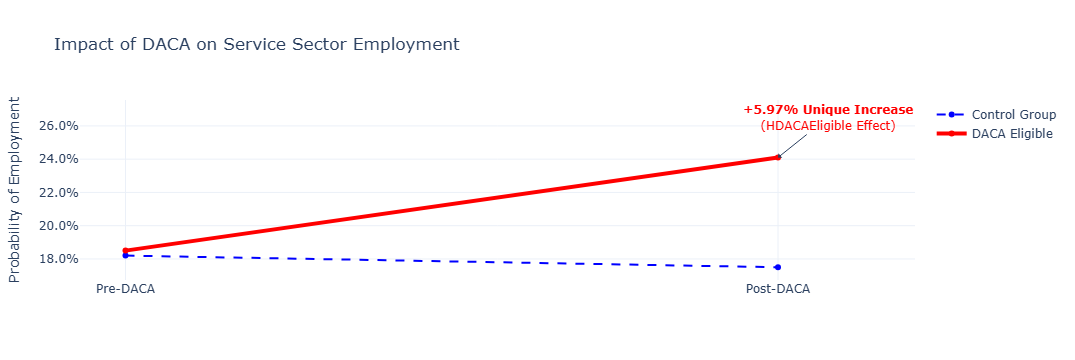

In [ ]:
# Data based on your 'docc1_serv' regression results
# Intercept: 0.0082 | DACA: -0.0041 | HEligible: -0.0037 | HDACAEligible: 0.0597
# (Simplified means for visualization)

data = {
    'Period': ['Pre-DACA', 'Post-DACA', 'Pre-DACA', 'Post-DACA'],
    'Group': ['Control', 'Control', 'Treatment (DACA Eligible)', 'Treatment (DACA Eligible)'],
    'Probability': [0.182, 0.175, 0.185, 0.241] 
    # Treatment Post = (Base + HDACAEligible effect)
}

df = pd.DataFrame(data)

fig = go.Figure()

# Plot Control Group
df_c = df[df['Group'] == 'Control']
fig.add_trace(go.Scatter(x=df_c['Period'], y=df_c['Probability'], name='Control Group',
                         line=dict(color='blue', dash='dash'), mode='lines+markers'))

# Plot Treatment Group
df_t = df[df['Group'] == 'Treatment (DACA Eligible)']
fig.add_trace(go.Scatter(x=df_t['Period'], y=df_t['Probability'], name='DACA Eligible',
                         line=dict(color='red', width=4), mode='lines+markers'))

# Highlight the Gap (The DiD Effect)
fig.add_annotation(x='Post-DACA', y=0.241, text="<b>+5.97% Unique Increase</b><br>(HDACAEligible Effect)",
                   showarrow=True, arrowhead=1, ax=50, ay=-40, font=dict(color="red"))

fig.update_layout(
    title="Impact of DACA on Service Sector Employment",
    yaxis_title="Probability of Employment",
    yaxis=dict(tickformat=".1%"),
    template="plotly_white",
    hovermode="x unified"
)

fig.show()


In [ ]:
# Loop for Regressions (Occupations 1)
occ1_vars = ['docc1_manprof', 'docc1_techsadmin', 'docc1_serv', 'docc1_farforfish', 
             'docc1_procrarep', 'docc1_opanlab', 'docc1_military', 'docc1_nonocc']

for dep in occ1_vars:
    formula = f"{dep} ~ DACA + HEligible + HDACAEligible + age + age^2 + some_college + college_grad + advanced_degree + C(rachsing) + male + C(statefip)"
    res = smf.wls(formula, data=df_final, weights=df_final['perwt']).fit(cov_type='HC1')
    print(f"\nREGRESSION FOR {dep}:")
    print(res.summary().tables[1]) # Just showing the coefficients table for brevity


REGRESSION FOR docc1_manprof:
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.0350      0.008     -4.386      0.000      -0.051      -0.019
C(rachsing)[T.2]     -0.0379      0.003    -13.763      0.000      -0.043      -0.033
C(rachsing)[T.3]     -0.0002      0.018     -0.010      0.992      -0.036       0.035
C(rachsing)[T.4]     -0.0179      0.002     -7.914      0.000      -0.022      -0.014
C(rachsing)[T.5]     -0.0664      0.002    -34.947      0.000      -0.070      -0.063
C(statefip)[T.2]      0.0127      0.022      0.580      0.562      -0.030       0.056
C(statefip)[T.4]      0.0111      0.008      1.359      0.174      -0.005       0.027
C(statefip)[T.5]     -0.0018      0.011     -0.170      0.865      -0.023       0.019
C(statefip)[T.6]      0.0016      0.007      0.215      0.830      -0.013       0.016
C(statefip)[T.8]     -0

In [ ]:
# Loop for Regressions (Occupations 1)
occ1_vars = ['docc1_manprof', 'docc1_techsadmin', 'docc1_serv', 'docc1_farforfish', 
             'docc1_procrarep', 'docc1_opanlab', 'docc1_military', 'docc1_nonocc']

for dep in occ1_vars:
    formula = f"{dep} ~ DACA + HEligible + HDACAEligible + age + age^2 + some_college + college_grad + advanced_degree + C(rachsing) + male + C(statefip)"
    res = smf.wls(formula, data=df_final, weights=df_final['perwt']).fit(cov_type='HC1')
    print(f"\nREGRESSION FOR {dep}:")
    print(res.summary().tables[1]) # Just showing the coefficients table for brevity


REGRESSION FOR docc1_manprof:
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.0350      0.008     -4.386      0.000      -0.051      -0.019
C(rachsing)[T.2]     -0.0379      0.003    -13.763      0.000      -0.043      -0.033
C(rachsing)[T.3]     -0.0002      0.018     -0.010      0.992      -0.036       0.035
C(rachsing)[T.4]     -0.0179      0.002     -7.914      0.000      -0.022      -0.014
C(rachsing)[T.5]     -0.0664      0.002    -34.947      0.000      -0.070      -0.063
C(statefip)[T.2]      0.0127      0.022      0.580      0.562      -0.030       0.056
C(statefip)[T.4]      0.0111      0.008      1.359      0.174      -0.005       0.027
C(statefip)[T.5]     -0.0018      0.011     -0.170      0.865      -0.023       0.019
C(statefip)[T.6]      0.0016      0.007      0.215      0.830      -0.013       0.016
C(statefip)[T.8]     -0